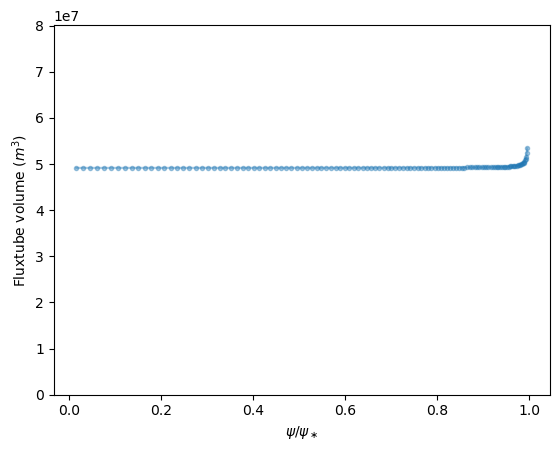

In [4]:
import numpy as np
from matplotlib import pyplot as plt
import sys

def psi_gen(psi_star, n_contours,MUMIN, MUMAX):
    mu_levels = np.empty(n_contours)
    for i in range(n_contours):
        mu_levels[i] = (n_contours - i)*MUMAX/(n_contours+1.) + (1 + i)/(n_contours+1.)*MUMIN

    return (psi_star)*(1-mu_levels*mu_levels)

B_star = 1.e8
R_star = 1.e4
psi_star = 0.5 * B_star*R_star**2
MUMIN = 0.
MUMAX = 1.
n_contours = 127
end_index = 120
psi_levels = psi_gen(psi_star, n_contours, MUMIN, MUMAX)

R_outer = R_star + 10

# volume between the pole and flux surface psi_lev, between radii R_star and radius. 
def flux_vol_term(psi_lev, psi_star, radius, R_star):
    return 4*np.pi/105.*(psi_star*R_star)**3/psi_lev**3*(1. - psi_lev*radius/psi_star/R_star)**1.5*(15.*(psi_lev/psi_star)**2*(radius/R_star)**2 + 12*(psi_lev/psi_star)*(radius/R_star) + 8)

def vol_to_radius_R(psi_lev, psi_star, radius, R_star):
    return flux_vol_term(psi_lev,psi_star, radius, R_star) - flux_vol_term(psi_lev,psi_star,R_star,R_star)

volumes = np.zeros(end_index)

for i in range(len(volumes)):
    volumes[i] = vol_to_radius_R(psi_levels[i+1],psi_star, R_outer,R_star) - vol_to_radius_R(psi_levels[i],psi_star, R_outer, R_star)

fig,ax = plt.subplots()
ax.plot(psi_levels[:end_index]/psi_star, volumes, '.-',alpha=0.4)
ax.set(ylim = [0, 1.5*np.max(volumes)], ylabel=r"Fluxtube volume $(m^3)$", xlabel=r"$\psi/\psi_\ast$")
plt.show()


The above plot demonstrates that, for a region close to the stellar surface $z\ll R_\ast$, the fluxtube volume is approximately constant (here we chose up to an altitude of $R_{\rm outer}=10.0\mathrm{m}$), up until close to the equator where the field lines start becoming closed. Inserting the same mass into each flux tube would yield, on average, the same density $\rho(\psi)\sim m(\psi)/V(\psi)$. So multiply through by the `angle_factor` to squash the behaviour at the pole. Testing this with `NT_ma_init_1e-8_b3_progdmdpsi_v13_01` as of 13/11/2025.